<a href="https://colab.research.google.com/github/selvimaharanip/bi-analyst-portfolio/blob/main/student-development-monitoring-dashboard/student_monitoring_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Development Monitoring Dashboard**

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Personal Project/Student Monitoring Dashboard/student_data.csv")

Seperti biasa mari kita familiarize ourselves with the data.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
df.describe(include="object")

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no
freq,349,208,307,281,354,141,217,145,273,344,242,214,201,314,375,329,263


Rename kolom

In [ ]:
df = df.rename(columns={
    "sex":"gender",
    "Medu":"mother_education",
    "Fedu":"father_education",
    "studytime":"study_time",
    "failures":"academic_failures",
    "G1":"grade_period1",
    "G2":"grade_period2",
    "G3":"final_grade"
})

In [ ]:
df.columns

Index(['school', 'gender', 'age', 'address', 'famsize', 'Pstatus',
       'mother_education', 'father_education', 'Mjob', 'Fjob', 'reason',
       'guardian', 'traveltime', 'study_time', 'academic_failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
       'health', 'absences', 'grade_period1', 'grade_period2', 'final_grade'],
      dtype='object')

In [ ]:
# cek statistik dasar
df[[
"age",
"study_time",
"academic_failures",
"absences",
"final_grade"
]].describe()

,age,study_time,academic_failures,absences,final_grade
count,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.035443,0.334177,5.708861,10.415190
std,1.276043,0.839240,0.743651,8.003096,4.581443
min,15.000000,1.000000,0.000000,0.000000,0.000000
25%,16.000000,1.000000,0.000000,0.000000,8.000000
50%,17.000000,2.000000,0.000000,4.000000,11.000000
75%,18.000000,2.000000,0.000000,8.000000,14.000000
max,22.000000,4.000000,3.000000,75.000000,20.000000


# **EXPLORATORY DATA ANALYSIS (EDA)**

1. Distribusi Final Grade

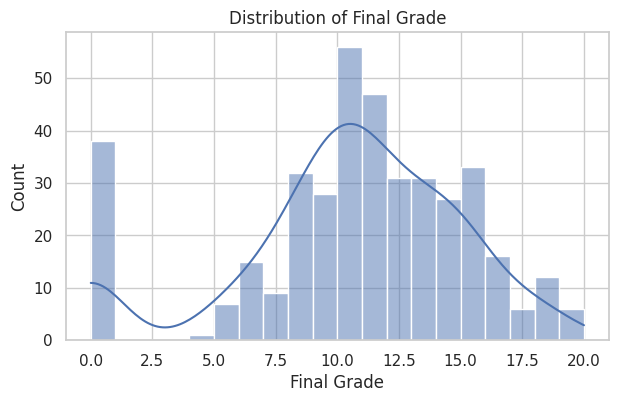

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df['final_grade'], bins=20, kde=True)
plt.title("Distribution of Final Grade")
plt.xlabel("Final Grade")
plt.show()

2. Distribusi Absences

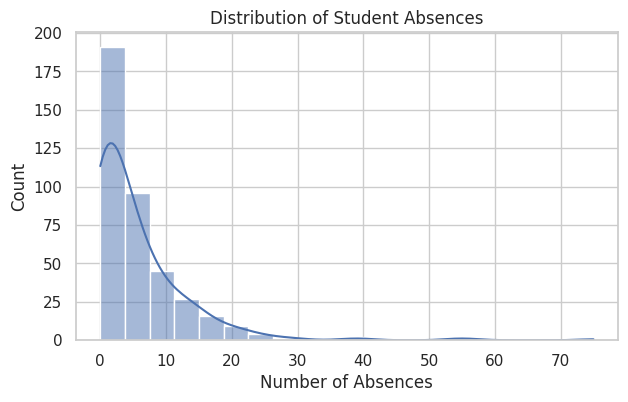

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df['absences'], bins=20, kde=True)
plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.show()

3. Distribusi Study Time

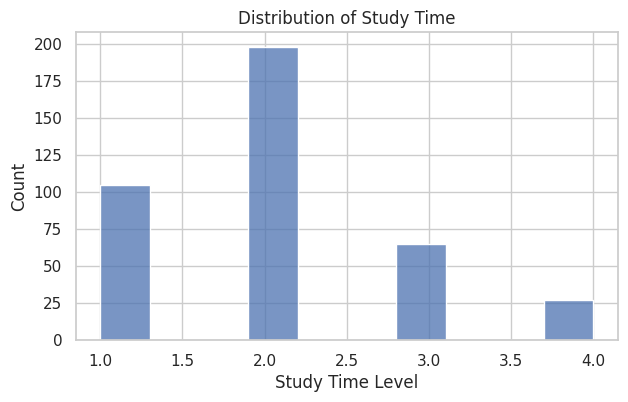

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df['study_time'], bins=10, kde=False)
plt.title("Distribution of Study Time")
plt.xlabel("Study Time Level")
plt.show()

4. Gender Distribution

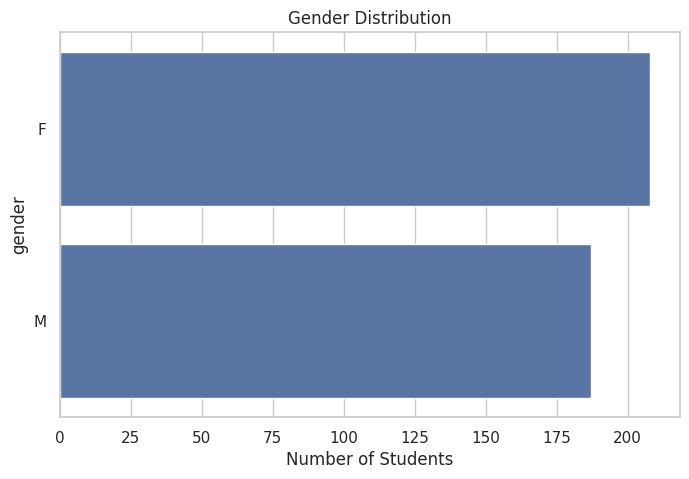

In [ ]:
gender_count = df['gender'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(y=gender_count.index, x=gender_count.values)
plt.title("Gender Distribution")
plt.xlabel("Number of Students")
plt.show()

5. Address Distribution (Urban vs Rural)

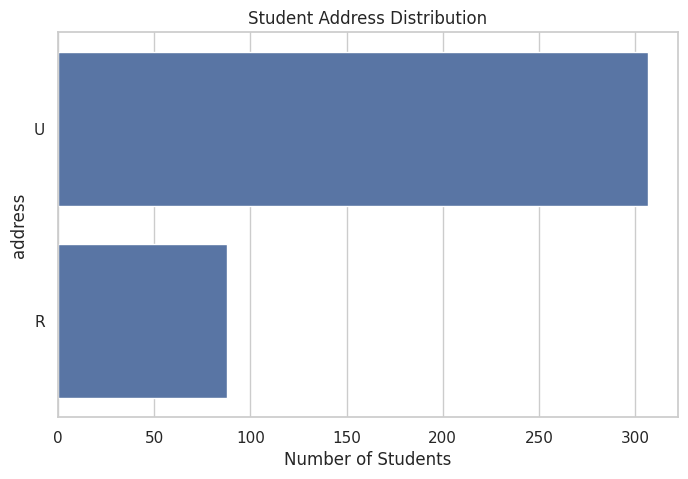

In [ ]:
address_count = df['address'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(y=address_count.index, x=address_count.values)
plt.title("Student Address Distribution")
plt.xlabel("Number of Students")
plt.show()

6. Parent Education Distribution

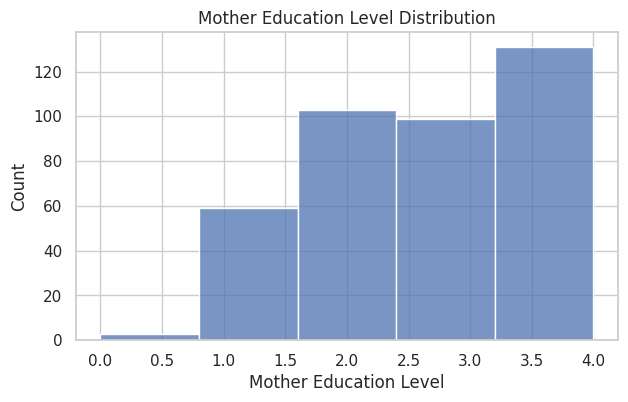

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df['mother_education'], bins=5, kde=False)
plt.title("Mother Education Level Distribution")
plt.xlabel("Mother Education Level")
plt.show()

Bivariate analysis

1. Study Time vs Final Grade

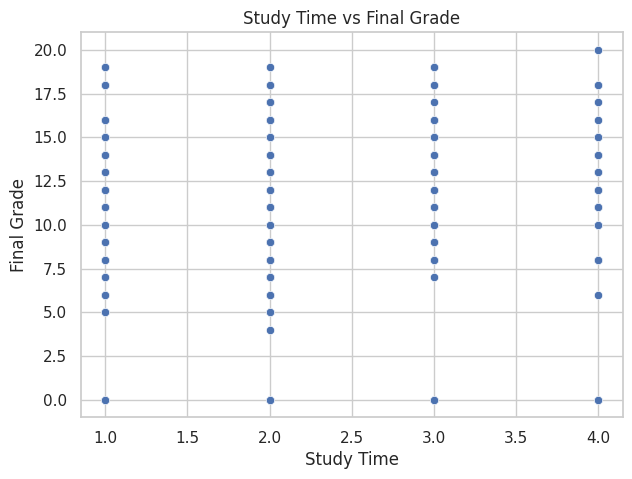

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='study_time', y='final_grade', data=df)
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.show()

2. Absences vs Final Grade

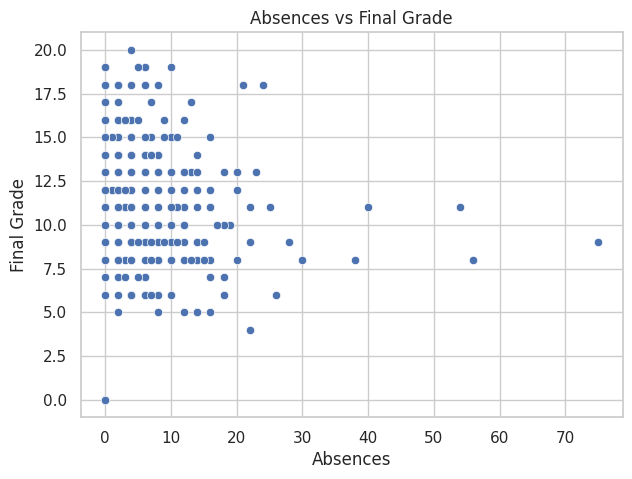

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='absences', y='final_grade', data=df)
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.show()

3. Academic Failures vs Final Grade

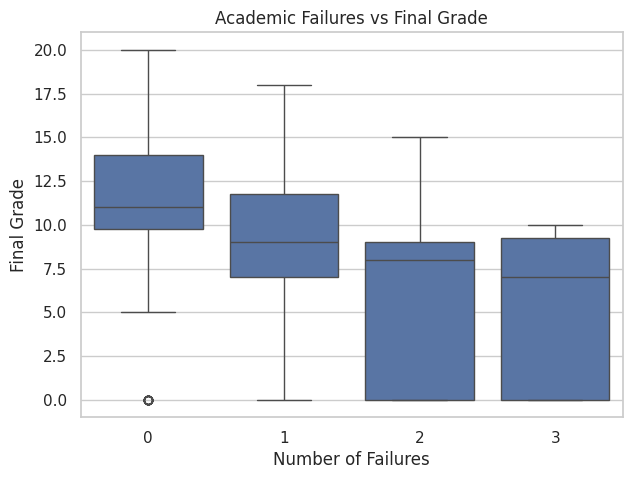

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='academic_failures', y='final_grade', data=df)
plt.title("Academic Failures vs Final Grade")
plt.xlabel("Number of Failures")
plt.ylabel("Final Grade")
plt.show()

4. Mother Education vs Final Grade

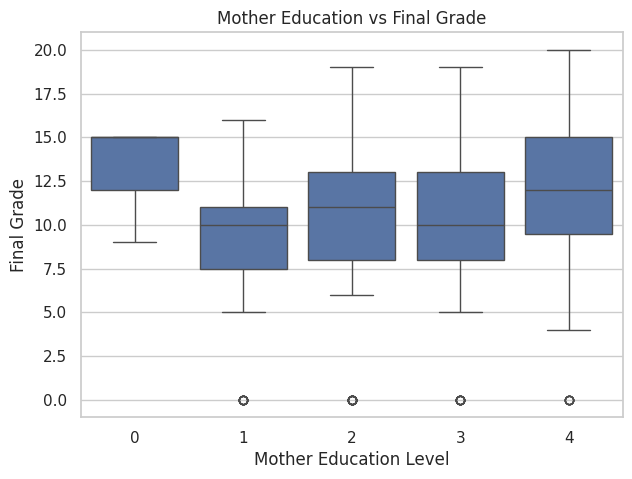

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='mother_education', y='final_grade', data=df)
plt.title("Mother Education vs Final Grade")
plt.xlabel("Mother Education Level")
plt.ylabel("Final Grade")
plt.show()

5. Gender vs Final Grade

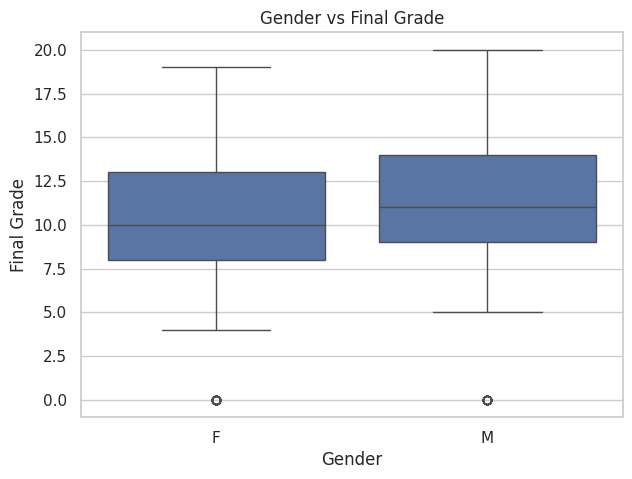

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='gender', y='final_grade', data=df)
plt.title("Gender vs Final Grade")
plt.xlabel("Gender")
plt.ylabel("Final Grade")
plt.show()

6. Correlation Matrix (Numerical Variables)

In [ ]:
plt.figure(figsize=(10,6))
corr = df[['age','study_time','academic_failures','absences','grade_period1','grade_period2','final_grade']].corr()

<Figure size 1000x600 with 0 Axes>

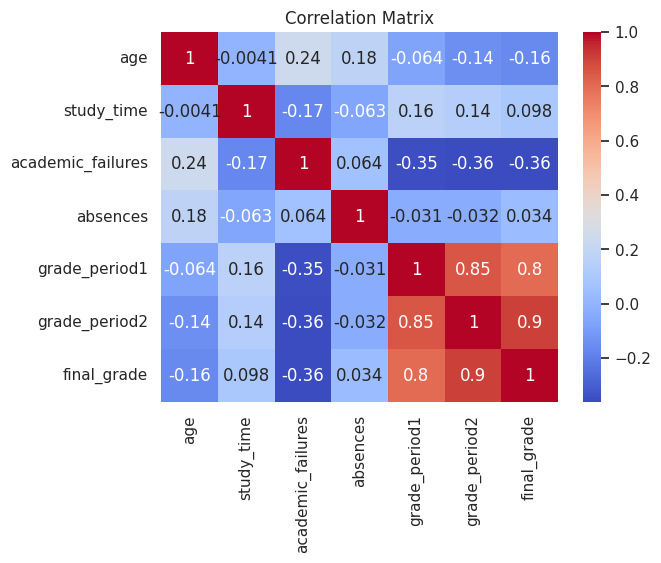

In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# **DATA CLEANING**

### Handling Missing Values

In [ ]:
# Checking missing values per records
df.isnull()

,school,gender,age,address,famsize,Pstatus,mother_education,father_education,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,grade_period1,grade_period2,final_grade
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
391,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
392,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
393,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Checking jumlah missing tiap kolom
df.isnull().sum()

,0
school,0
gender,0
age,0
address,0
famsize,0
Pstatus,0
mother_education,0
father_education,0
Mjob,0
Fjob,0


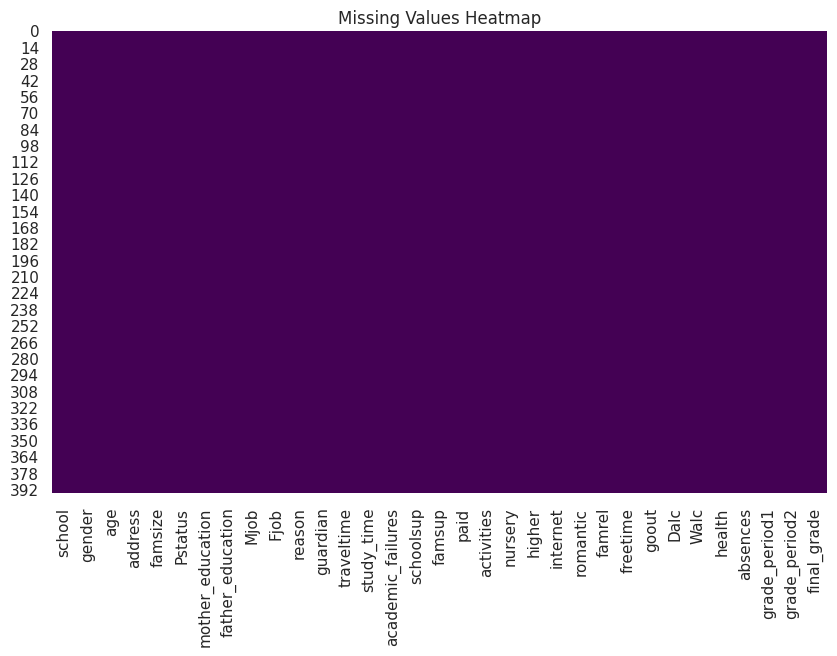

In [ ]:
# Visualisasi Missing Values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### Handling Outlier

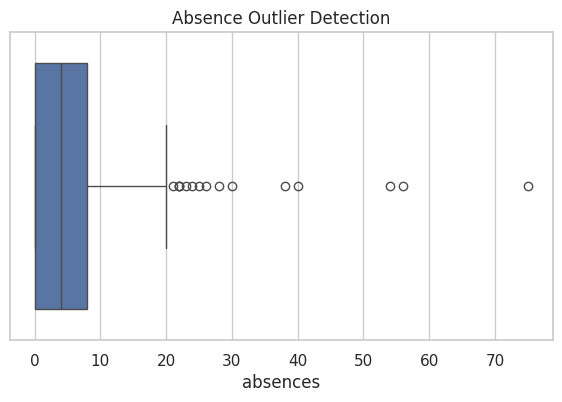

In [ ]:
# absences:

plt.figure(figsize=(7,4))
sns.boxplot(x=df['absences'])
plt.title("Absence Outlier Detection")
plt.show()

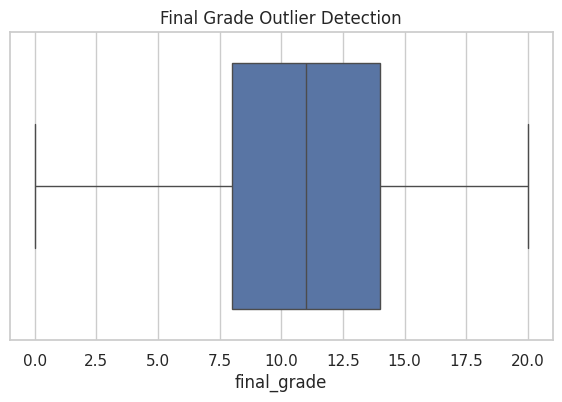

In [ ]:
# final grade:

plt.figure(figsize=(7,4))
sns.boxplot(x=df['final_grade'])
plt.title("Final Grade Outlier Detection")
plt.show()

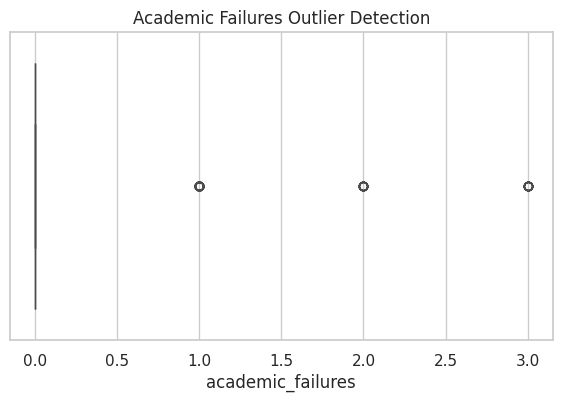

In [ ]:
# academic failures:

plt.figure(figsize=(7,4))
sns.boxplot(x=df['academic_failures'])
plt.title("Academic Failures Outlier Detection")
plt.show()

### Handling Duplicate Values

In [ ]:
# Check duplicate per row
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
390,False
391,False
392,False
393,False


In [ ]:
# Jumlah duplicate
df.duplicated().sum()

np.int64(0)

### Mengubah Format Data

In [ ]:
# Cek tipe data awal
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   school             395 non-null    object
 1   gender             395 non-null    object
 2   age                395 non-null    int64 
 3   address            395 non-null    object
 4   famsize            395 non-null    object
 5   Pstatus            395 non-null    object
 6   mother_education   395 non-null    int64 
 7   father_education   395 non-null    int64 
 8   Mjob               395 non-null    object
 9   Fjob               395 non-null    object
 10  reason             395 non-null    object
 11  guardian           395 non-null    object
 12  traveltime         395 non-null    int64 
 13  study_time         395 non-null    int64 
 14  academic_failures  395 non-null    int64 
 15  schoolsup          395 non-null    object
 16  famsup             395 non-null    object
 1

In [ ]:
# Convert Object ke Category
categorical_cols = [
    'school',
    'gender',
    'address',
    'famsize',
    'Pstatus',
    'Mjob',
    'Fjob',
    'reason',
    'guardian',
    'schoolsup',
    'famsup',
    'paid',
    'activities',
    'nursery',
    'higher',
    'internet',
    'romantic'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [ ]:
# Final Check Setelah Cleaning

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   school             395 non-null    category
 1   gender             395 non-null    category
 2   age                395 non-null    int64   
 3   address            395 non-null    category
 4   famsize            395 non-null    category
 5   Pstatus            395 non-null    category
 6   mother_education   395 non-null    int64   
 7   father_education   395 non-null    int64   
 8   Mjob               395 non-null    category
 9   Fjob               395 non-null    category
 10  reason             395 non-null    category
 11  guardian           395 non-null    category
 12  traveltime         395 non-null    int64   
 13  study_time         395 non-null    int64   
 14  academic_failures  395 non-null    int64   
 15  schoolsup          395 non-null    category
 16  famsup  

In [ ]:
df.describe()

,age,mother_education,father_education,traveltime,study_time,academic_failures,famrel,freetime,goout,Dalc,Walc,health,absences,grade_period1,grade_period2,final_grade
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# **FEATURE ENGINEERING**

Performance Category

Mengelompokkan siswa berdasarkan final academic performance.

In [ ]:
def performance_category(grade):
    if grade >= 14:
        return "High Performing"
    elif grade >= 10:
        return "Moderate"
    else:
        return "At Risk"

df["performance_category"] = df["final_grade"].apply(performance_category)

In [ ]:
df["performance_category"].value_counts()

,count
performance_category,
Moderate,165
At Risk,130
High Performing,100


Risk Flag

Membuat indikator student risk monitoring.

Kriteria siswa dianggap berisiko:
- nilai akhir rendah
- absensi tinggi
- pernah gagal akademik

In [ ]:
df["risk_flag"] = np.where(
(df["final_grade"] < 10) |
(df["absences"] > 10) |
(df["academic_failures"] > 0),
"At Risk",
"Normal"
)

In [ ]:
df["risk_flag"].value_counts()

,count
risk_flag,
Normal,210
At Risk,185


Absence Level

Mengelompokkan tingkat absensi siswa.

In [ ]:
def absence_level(absences):
    if absences <= 5:
        return "Low"
    elif absences <= 15:
        return "Moderate"
    else:
        return "High"

df["absence_level"] = df["absences"].apply(absence_level)

In [ ]:
df["absence_level"].value_counts()

,count
absence_level,
Low,249
Moderate,113
High,33


Study Time Category

Mengubah skala study time menjadi kategori yang lebih mudah dibaca.

In [ ]:
studytime_map = {
    1: "<2 hours",
    2: "2-5 hours",
    3: "5-10 hours",
    4: ">10 hours"
}

df["study_time_category"] = df["study_time"].map(studytime_map)

In [ ]:
df["study_time_category"].value_counts()

,count
study_time_category,
2-5 hours,198
<2 hours,105
5-10 hours,65
>10 hours,27


Academic Progress Indicator

Mengukur perkembangan nilai siswa dari:

grade_period1 → grade_period2 → final_grade

In [ ]:
df["grade_progress"] = df["final_grade"] - df["grade_period1"]

Progress Category

Kategori perkembangan akademik.

In [ ]:
def progress_category(progress):
    if progress > 0:
        return "Improved"
    elif progress == 0:
        return "Stable"
    else:
        return "Declined"

df["progress_category"] = df["grade_progress"].apply(progress_category)

In [ ]:
df["progress_category"].value_counts()

,count
progress_category,
Declined,159
Improved,143
Stable,93


Urutkan kolom

In [ ]:
column_order = [

# Demographic
"school",
"gender",
"age",
"address",
"famsize",
"Pstatus",
"guardian",

# Family background
"mother_education",
"father_education",
"Mjob",
"Fjob",

# Student behaviour & support
"study_time",
"traveltime",
"schoolsup",
"famsup",
"paid",
"activities",
"internet",
"romantic",
"freetime",
"goout",
"Dalc",
"Walc",
"health",

# Academic performance
"academic_failures",
"absences",
"grade_period1",
"grade_period2",
"final_grade",

# Feature engineering
"performance_category",
"risk_flag",
"absence_level",
"study_time_category",
"grade_progress",
"progress_category"

]

df = df[column_order]

Convert Feature Columns

In [ ]:
feature_cols = [
"performance_category",
"risk_flag",
"absence_level",
"study_time_category",
"progress_category"
]

for col in feature_cols:
    df[col] = df[col].astype("category")

**Final Dataset Check**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   school                395 non-null    category
 1   gender                395 non-null    category
 2   age                   395 non-null    int64   
 3   address               395 non-null    category
 4   famsize               395 non-null    category
 5   Pstatus               395 non-null    category
 6   guardian              395 non-null    category
 7   mother_education      395 non-null    int64   
 8   father_education      395 non-null    int64   
 9   Mjob                  395 non-null    category
 10  Fjob                  395 non-null    category
 11  study_time            395 non-null    int64   
 12  traveltime            395 non-null    int64   
 13  schoolsup             395 non-null    category
 14  famsup                395 non-null    category
 15  paid  

In [ ]:
df.head()

,school,gender,age,address,famsize,Pstatus,guardian,mother_education,father_education,Mjob,...,absences,grade_period1,grade_period2,final_grade,performance_category,risk_flag,absence_level,study_time_category,grade_progress,progress_category
0,GP,F,18,U,GT3,A,mother,4,4,at_home,...,6,5,6,6,At Risk,At Risk,Moderate,2-5 hours,1,Improved
1,GP,F,17,U,GT3,T,father,1,1,at_home,...,4,5,5,6,At Risk,At Risk,Low,2-5 hours,1,Improved
2,GP,F,15,U,LE3,T,mother,1,1,at_home,...,10,7,8,10,Moderate,At Risk,Moderate,2-5 hours,3,Improved
3,GP,F,15,U,GT3,T,mother,4,2,health,...,2,15,14,15,High Performing,Normal,Low,5-10 hours,0,Stable
4,GP,F,16,U,GT3,T,father,3,3,other,...,4,6,10,10,Moderate,Normal,Low,2-5 hours,4,Improved


In [ ]:
df.describe()

,age,mother_education,father_education,study_time,traveltime,freetime,goout,Dalc,Walc,health,academic_failures,absences,grade_period1,grade_period2,final_grade,grade_progress
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,2.035443,1.448101,3.235443,3.108861,1.481013,2.291139,3.554430,0.334177,5.708861,10.908861,10.713924,10.415190,-0.493671
std,1.276043,1.094735,1.088201,0.839240,0.697505,0.998862,1.113278,0.890741,1.287897,1.390303,0.743651,8.003096,3.319195,3.761505,4.581443,2.762482
min,15.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,-12.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,8.000000,9.000000,8.000000,-1.000000
50%,17.000000,3.000000,2.000000,2.000000,1.000000,3.000000,3.000000,1.000000,2.000000,4.000000,0.000000,4.000000,11.000000,11.000000,11.000000,0.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,4.000000,4.000000,2.000000,3.000000,5.000000,0.000000,8.000000,13.000000,13.000000,14.000000,1.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,75.000000,19.000000,19.000000,20.000000,4.000000


# **Export cleaned dataset**

In [ ]:
df.to_excel("student_dashboard_data.xlsx", index=False)

In [ ]:
df.to_excel("/content/drive/MyDrive/Colab Notebooks/Personal Project/Student Monitoring Dashboard/student_monitoring_dashboard_data.xlsx", index=False)